ابزارهای لازم برای محاسبات، کاهش ابعاد و ترسیم نمودار

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

plt.style.use('ggplot')

در این بخش، ابتدا داده‌ها را استاندارد کرده و سپس تاثیر کاهش بعد بدون نظارت (PCA) را با روش نظارت‌شده (LDA) مقایسه می‌کنیم.

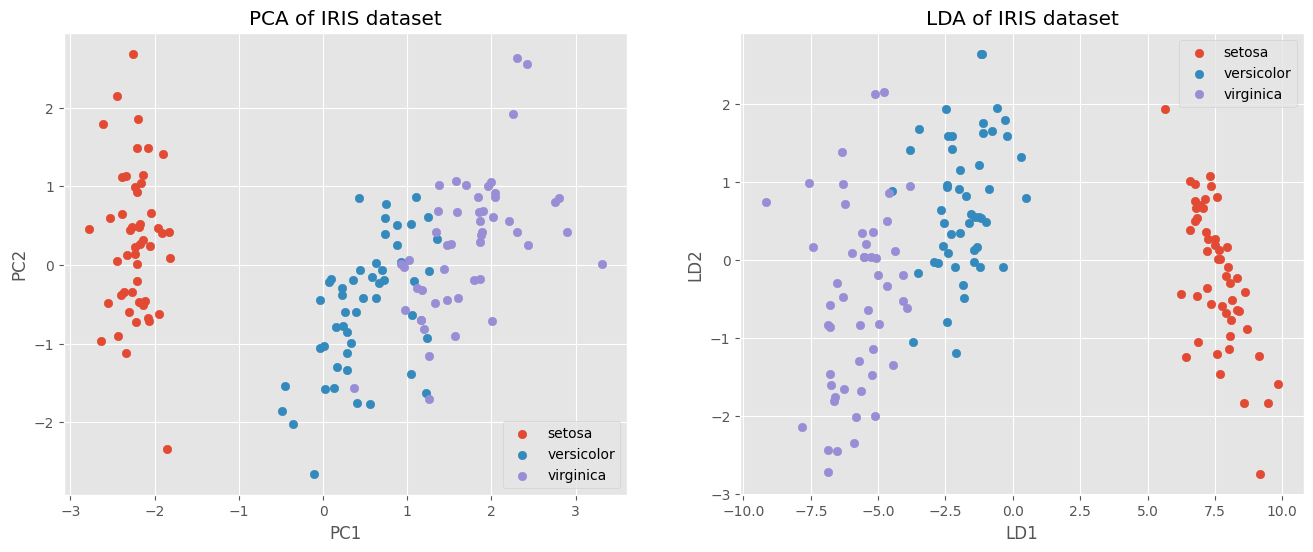

In [2]:

iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for i, target_name in enumerate(target_names):
    ax1.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=target_name)
ax1.set_title('PCA of IRIS dataset')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.legend()

for i, target_name in enumerate(target_names):
    ax2.scatter(X_lda[y == i, 0], X_lda[y == i, 1], label=target_name)
ax2.set_title('LDA of IRIS dataset')
ax2.set_xlabel('LD1')
ax2.set_ylabel('LD2')
ax2.legend()

plt.show()

درک اینکه ۲ مولفه چقدر از اطلاعات را حفظ کرده‌اند

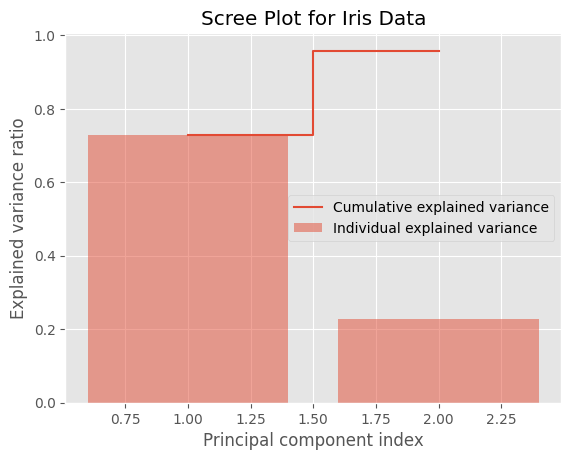

In [3]:

exp_var_pca = pca.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

plt.bar(range(1, len(exp_var_pca)+1), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(cum_sum_eigenvalues)+1), cum_sum_eigenvalues, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.title('Scree Plot for Iris Data')
plt.show()

در این بخش داده‌های دایره‌ای تولید می‌کنیم که در فضای ۲ بعدی با خط جدا نمی‌شوند و سپس با استفاده از یک هسته آن‌ها را تفکیک می‌کنیم.

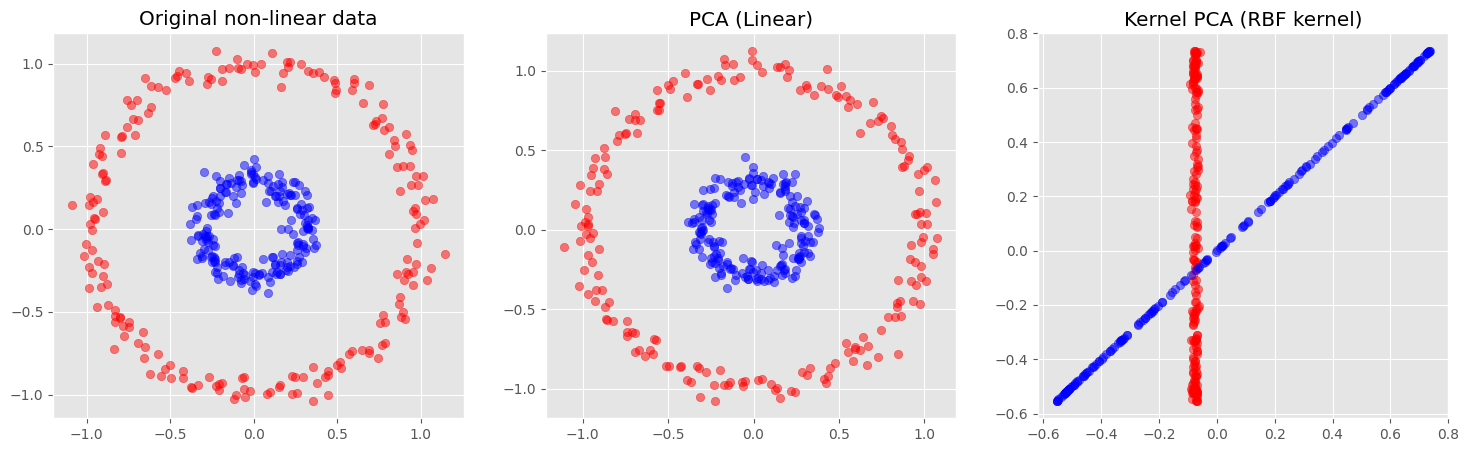

In [4]:

X_circles, y_circles = make_circles(n_samples=400, factor=.3, noise=.05, random_state=42)

pca_l = PCA(n_components=2)
X_pca_l = pca_l.fit_transform(X_circles)

kpca = KernelPCA(kernel="rbf", fit_inverse_transform=True, gamma=10)
X_kpca = kpca.fit_transform(X_circles)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.scatter(X_circles[y_circles == 0, 0], X_circles[y_circles == 0, 1], color='red', alpha=0.5)
ax1.scatter(X_circles[y_circles == 1, 0], X_circles[y_circles == 1, 1], color='blue', alpha=0.5)
ax1.set_title('Original non-linear data')

ax2.scatter(X_pca_l[y_circles == 0, 0], X_pca_l[y_circles == 0, 1], color='red', alpha=0.5)
ax2.scatter(X_pca_l[y_circles == 1, 0], X_pca_l[y_circles == 1, 1], color='blue', alpha=0.5)
ax2.set_title('PCA (Linear)')

ax3.scatter(X_kpca[y_circles == 0, 0], X_kpca[y_circles == 1, 0], color='red', alpha=0.5)
ax3.scatter(X_kpca[y_circles == 1, 0], X_kpca[y_circles == 1, 0], color='blue', alpha=0.5)
ax3.set_title('Kernel PCA (RBF kernel)')

plt.show()

**سوال 8**:

در این مرحله ابتدا داده‌ها را فراخوانی کرده و ماتریس همبستگی را برای شناسایی روابط بین ویژگی‌ها رسم می‌کنیم

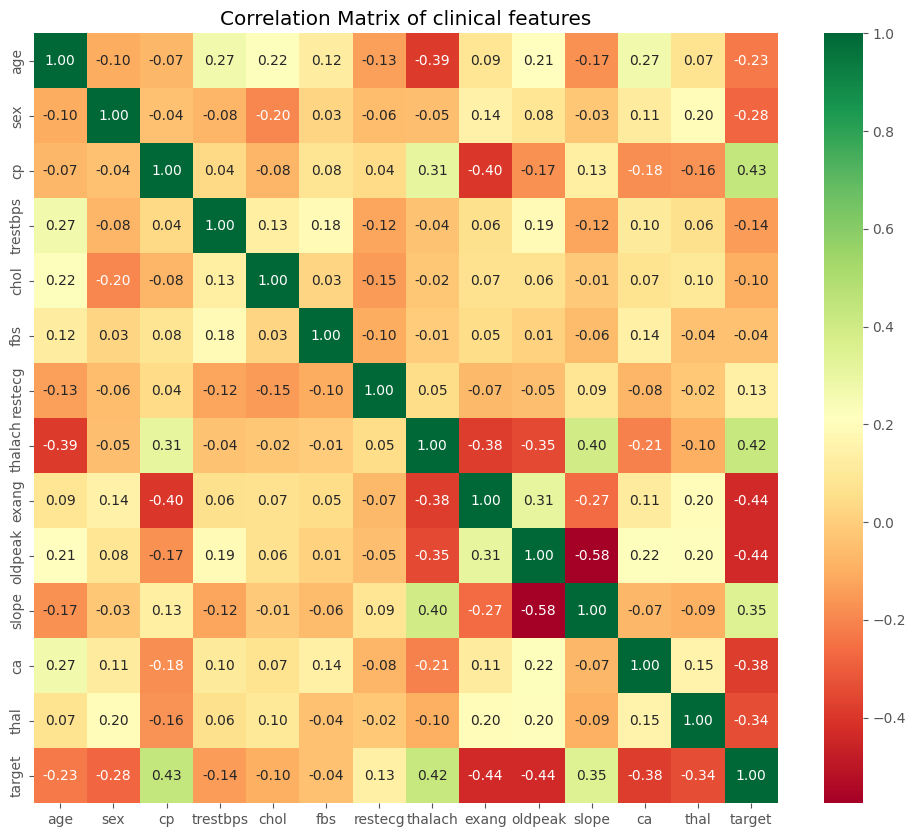

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# بارگذاری فایل اکسل (نام فایل را دقیق چک کنید)
df = pd.read_csv('heart.csv')

# بررسی و حذف مقادیر گم‌شده برای جلوگیری از خطا در مدل
df = df.dropna()

# رسم ماتریس همبستگی برای تحلیل روابط ویژگی‌ها
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Matrix of clinical features')
plt.show()

طبق صورت سوال، باید ویژگی‌های تکراری یا Redundant را شناسایی و حذف کنیم

In [13]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. آماده‌سازی داده‌ها
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. روش Univariate (Mutual Information)
selector = SelectKBest(score_func=mutual_info_classif, k=5)
X_train_mi = selector.fit_transform(X_train, y_train)
X_test_mi = selector.transform(X_test)
mi_features = X.columns[selector.get_support()]

# 3. روش Wrapper (RFE)
rfe = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=5)
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)
rfe_features = X.columns[rfe.support_]

# 4. ارزیابی و مقایسه
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)
acc_full = accuracy_score(y_test, model.predict(X_test))

model.fit(X_train_mi, y_train)
acc_mi = accuracy_score(y_test, model.predict(X_test_mi))

model.fit(X_train_rfe, y_train)
acc_rfe = accuracy_score(y_test, model.predict(X_test_rfe))

print(f"Top Features (MI): {list(mi_features)}")
print(f"Top Features (RFE): {list(rfe_features)}")
print(f"Accuracy (Full: {acc_full:.2f}, MI: {acc_mi:.2f}, RFE: {acc_rfe:.2f})")

Top Features (MI): ['chol', 'thalach', 'oldpeak', 'ca', 'thal']
Top Features (RFE): ['sex', 'cp', 'exang', 'oldpeak', 'thal']
Accuracy (Full: 0.80, MI: 0.73, RFE: 0.80)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Optimal number of features: 11
Selected Features by RFECV: ['sex', 'cp', 'trestbps', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


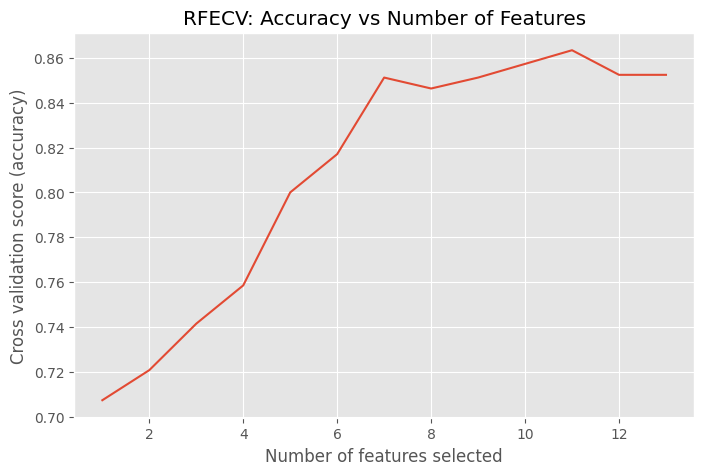

In [14]:
from sklearn.feature_selection import RFECV

# استفاده از RFECV برای یافتن تعداد بهینه ویژگی‌ها
# cv=5 یعنی داده‌ها به 5 بخش تقسیم می‌شوند تا نتایج پایدارتر باشد
rfecv = RFECV(estimator=LogisticRegression(max_iter=1000), step=1, cv=5)
rfecv.fit(X_train, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Selected Features by RFECV: {list(X.columns[rfecv.support_])}")

# رسم نمودار عملکرد بر حسب تعداد ویژگی‌ها
plt.figure(figsize=(8, 5))
plt.xlabel("Number of features selected")
plt.ylabel("Cross validation score (accuracy)")
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.title("RFECV: Accuracy vs Number of Features")
plt.show()

Lasso Selected Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


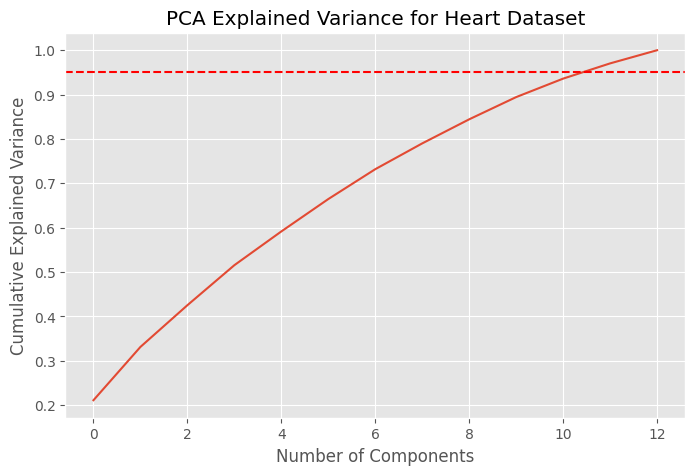

Number of PCA components needed for 95% variance: 12


In [15]:
from sklearn.linear_model import LassoCV
from sklearn.decomposition import PCA

# 1. روش Lasso (Embedded)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = LassoCV(cv=5).fit(X_train_scaled, y_train)
lasso_features = X.columns[np.abs(lasso.coef_) > 1e-5]
print(f"Lasso Selected Features: {list(lasso_features)}")

# 2. تحلیل PCA (Exploratory Tool)
pca = PCA().fit(X_train_scaled)
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance for Heart Dataset')
plt.axhline(y=0.95, color='r', linestyle='--') # خط 95 درصد اطلاعات
plt.show()

# محاسبه تعداد مولفه‌های لازم برای 95 درصد واریانس
n_components_95 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
print(f"Number of PCA components needed for 95% variance: {n_components_95}")

**سوال 9:**

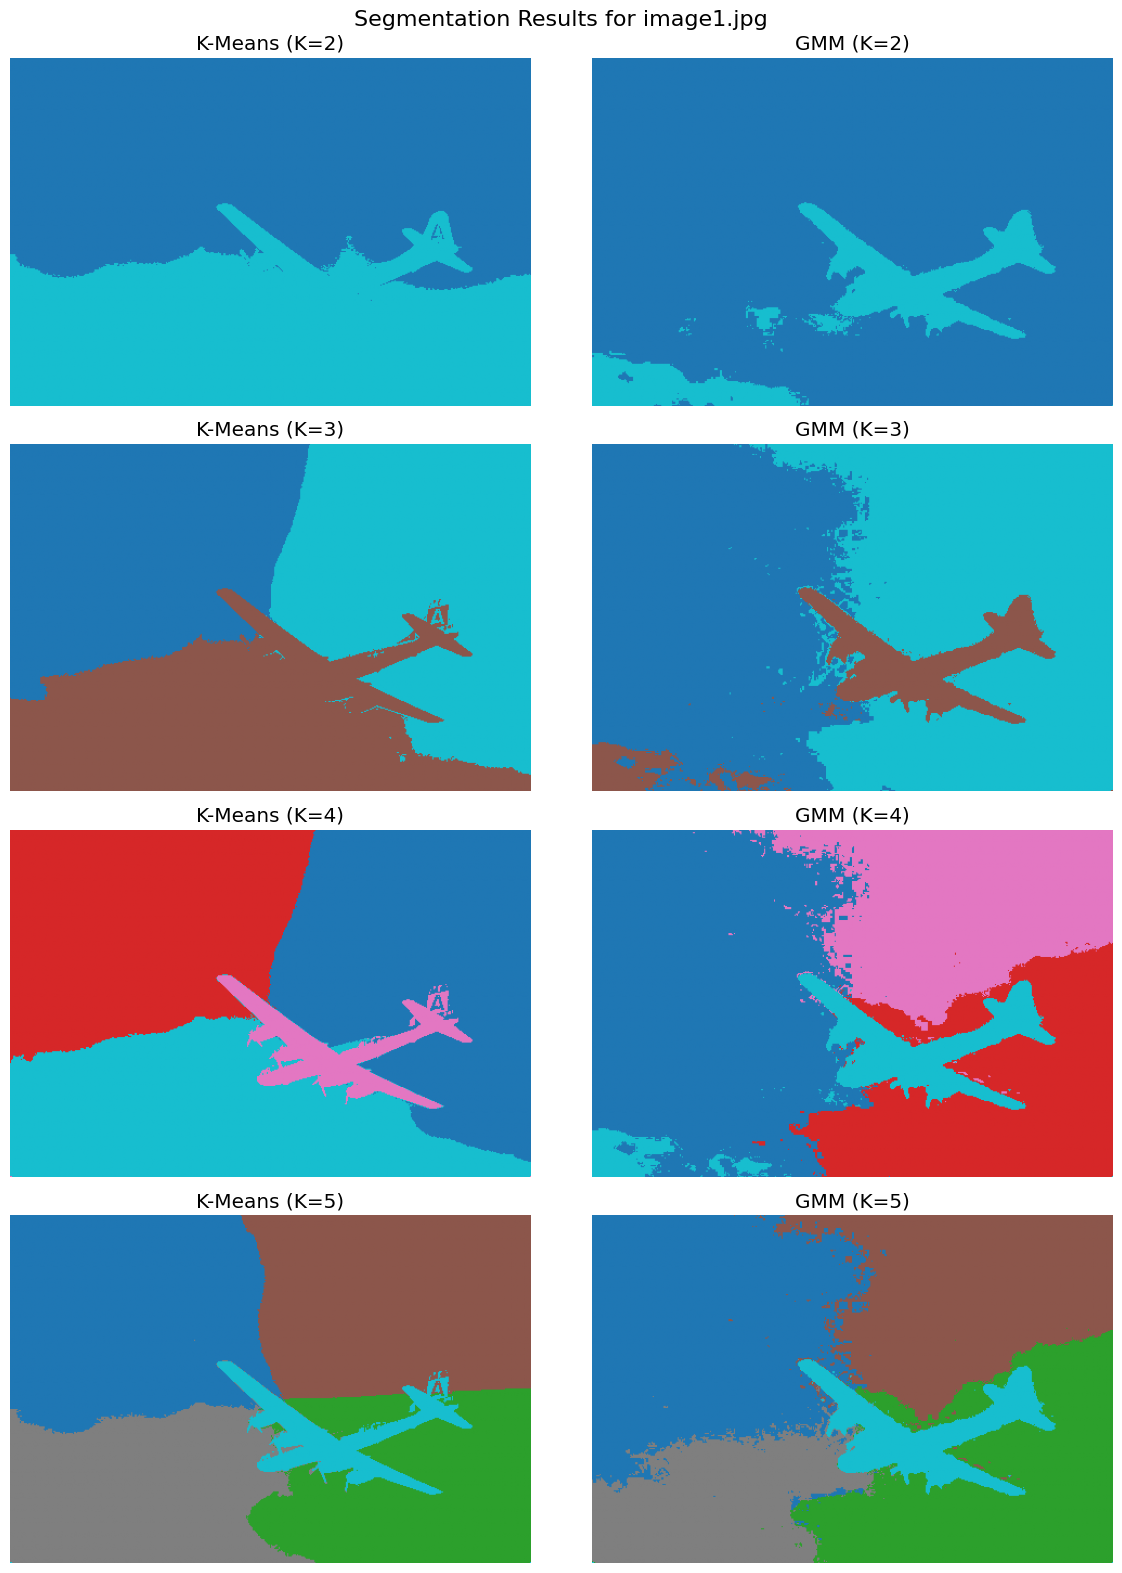

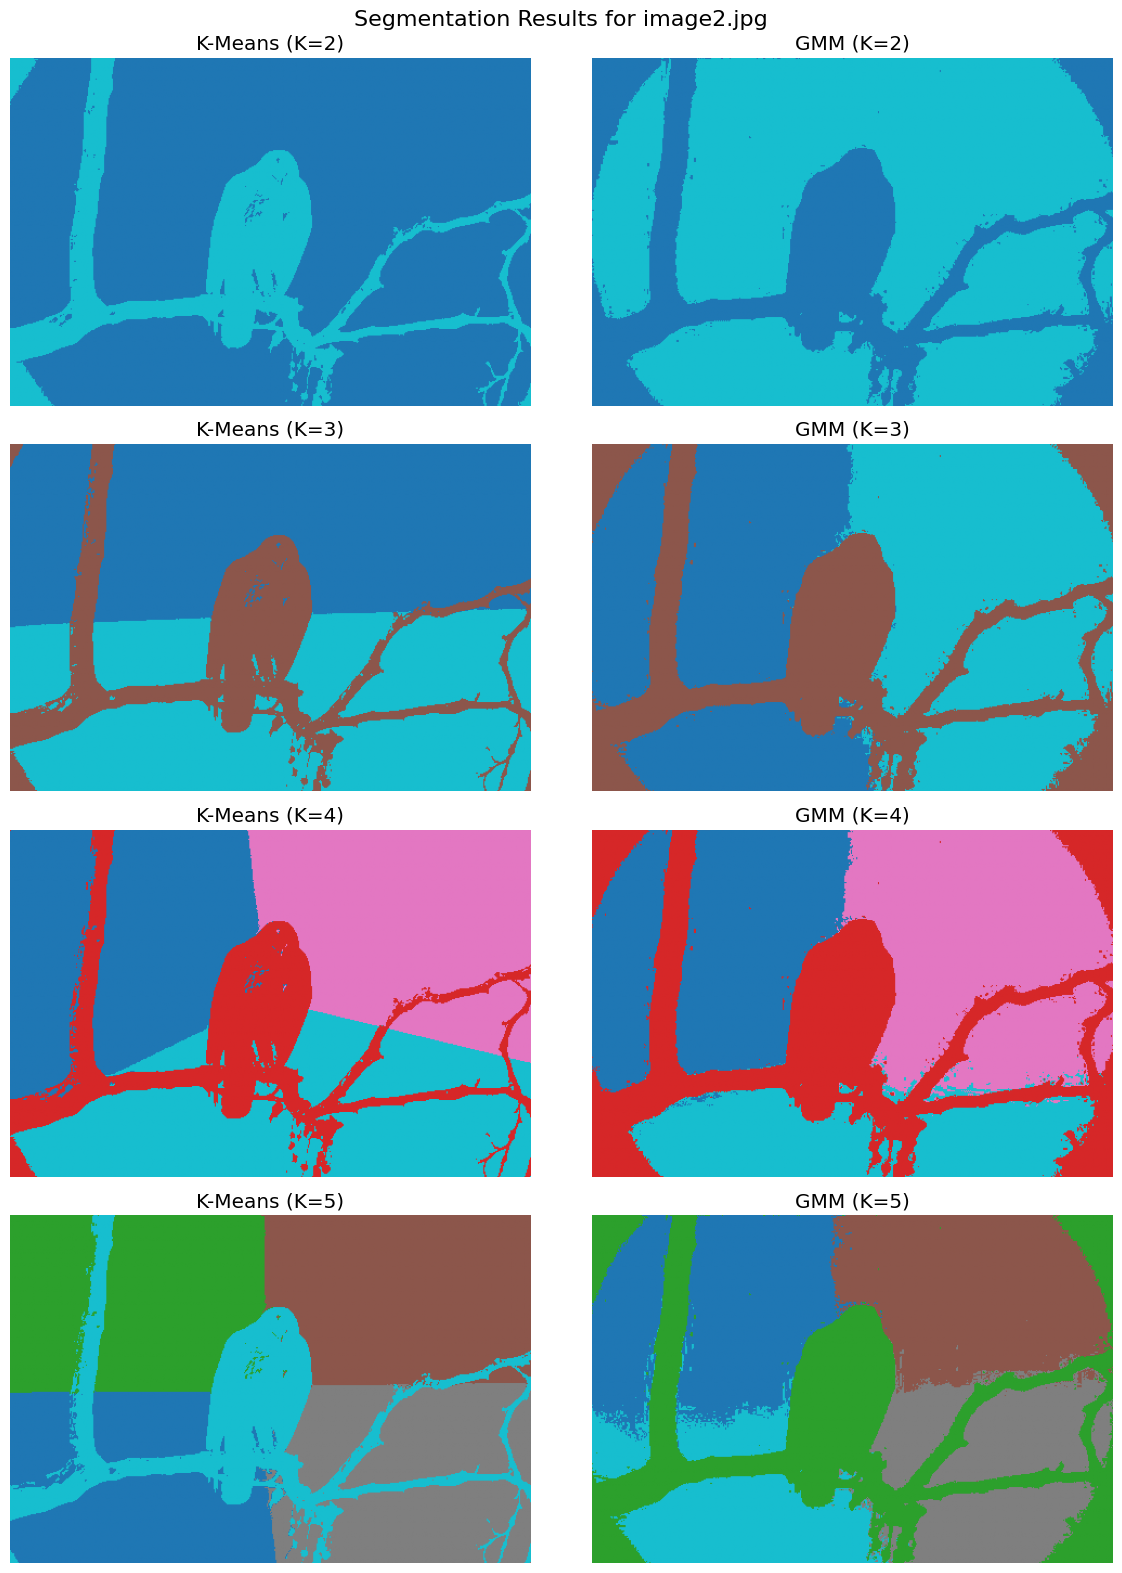

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler
import cv2

def segment_image(image_path, k_values=[2, 3, 4, 5]):
    # بارگذاری تصویر
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    h, w, c = img.shape

    # استخراج ویژگی‌های 5 بعدی (سطر، ستون، قرمز، سبز، آبی)
    rows, cols = np.indices((h, w))
    features = np.stack([rows.ravel(), cols.ravel(),
                         img[:,:,0].ravel(), img[:,:,1].ravel(), img[:,:,2].ravel()], axis=1)

    # نرمال‌سازی در بازه [0, 1] طبق صورت سوال
    scaler = MinMaxScaler()
    features_scaled = scaler.fit_transform(features)

    # ترسیم نتایج
    fig, axes = plt.subplots(len(k_values), 2, figsize=(12, 16))
    fig.suptitle(f'Segmentation Results for {image_path}', fontsize=16)

    for i, k in enumerate(k_values):
        # اجرای K-Means
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels_km = kmeans.fit_predict(features_scaled).reshape(h, w)

        # اجرای GMM
        gmm = GaussianMixture(n_components=k, random_state=42)
        labels_gmm = gmm.fit_predict(features_scaled).reshape(h, w)

        # نمایش خروجی‌ها
        axes[i, 0].imshow(labels_km, cmap='tab10')
        axes[i, 0].set_title(f'K-Means (K={k})')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(labels_gmm, cmap='tab10')
        axes[i, 1].set_title(f'GMM (K={k})')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

segment_image('image1.jpg')
segment_image('image2.jpg')